In [ ]:
import torch
import sionna

print(torch.__version__)
print(sionna.__version__)

print("CUDA available: ", torch.cuda.is_available())

if torch.cuda.is_available( ):
    print("GPU device name:", torch.cuda.get_device_name())

2.11.0+cpu
2.0.1
CUDA available:  False


In [ ]:
from sionna.phy.channel.tr38901 import UMa, PanelArray
carrier_frequency = 3.5e9  # 载波频率, 单位 Hz

ut_array = PanelArray(num_rows_per_panel=1, num_cols_per_panel=1,
                     polarization='single', polarization_type='V',
                     antenna_pattern='omni', carrier_frequency=carrier_frequency)  # 一个天线阵列

bs_array = PanelArray(num_rows_per_panel=1, num_cols_per_panel=4,
                      polarization='single', polarization_type='V',
                       antenna_pattern='38.901', carrier_frequency=carrier_frequency)
# 创建一个UMa信道模型
channel_model = UMa(
    carrier_frequency=carrier_frequency,
    o2i_model="low",
    ut_array=ut_array,
    bs_array=bs_array,
    direction="downlink",
    enable_pathloss=True,
    enable_shadow_fading=True,
)

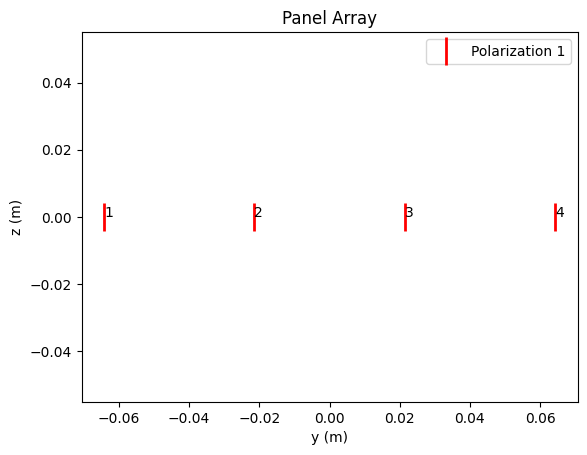

In [ ]:
bs_array.show()

In [ ]:
ut_loc = torch.tensor(
    [[[100.0, 0.0, 1.5]]],
    dtype=torch.float32,
)
bs_loc = torch.tensor(
    [[[0.0, 0.0, 25.0]]],
    dtype=torch.float32,
)
# bs_loc.shape
batch_size, num_ut, num_bs = 1, 1, 1
bs_orientation = torch.zeros(   # 设备的旋转姿态
    (batch_size, num_bs, 3),
    dtype=torch.float32,
)

ut_orientation = torch.zeros(
    (batch_size, num_ut, 3),
    dtype=torch.float32,
)

ut_velocities = torch.zeros(  # 设备的移动速度
    (batch_size, num_ut, 3),
    dtype=torch.float32,
)
in_state = torch.tensor( # 室内/室外状态
    [[False]],
    dtype=torch.bool,
)
los = False


In [ ]:
channel_model.set_topology(
    ut_loc=ut_loc,
    bs_loc=bs_loc,
    ut_orientations=ut_orientation,
    bs_orientations=bs_orientation,
    ut_velocities=ut_velocities,
    in_state=in_state,
    los=False,
)

In [ ]:
num_time_samples = 1
sampling_frequency = 1.0  # 采样频率 [Hz]，采样时间间隔 [s]=1/num_time_samples


# a: [batch size, num_rx, num_rx_ant, num_tx, num_tx_ant, num_paths, num_time_samples], `torch.complex`. Path coefficients.
#  tau: [batch size, num_rx, num_tx, num_paths], `torch.float`. Path delays [s].
a, tau = channel_model(
    num_time_samples=num_time_samples,
    sampling_frequency=sampling_frequency,
)

In [ ]:
print("\n=== CIR information ===")

print("\na:")
print("type :", type(a))
print("dtype:", a.dtype)
print("shape:", a.shape)
# print("data:", a)

print("\ntau:")
print("type :", type(tau))
print("dtype:", tau.dtype)
print("shape:", tau.shape)
# print("data:", tau)




=== CIR information ===

a:
type : <class 'torch.Tensor'>
dtype: torch.complex64
shape: torch.Size([1, 1, 1, 1, 4, 24, 1])

tau:
type : <class 'torch.Tensor'>
dtype: torch.float32
shape: torch.Size([1, 1, 1, 24])


In [ ]:
print("\nNumber of paths:")
print(a.shape[-2])


Number of paths:
24


In [ ]:
a_link = a[
    0,  # batch
    0,  # UT
    0,  # UT antenna
    0,  # BS
    0,  # BS antenna
    :,  # all paths
    0,  # time sample
]

print("\nPath coefficients for BS antenna 0 -> UT antenna 0:")
print(a_link)


Path coefficients for BS antenna 0 -> UT antenna 0:
tensor([ 6.0713e-07+1.1597e-06j,  2.2444e-06-9.3188e-07j,
         2.6146e-07+6.8225e-07j, -8.7221e-07-1.1453e-06j,
         4.3991e-08-9.3630e-07j,  1.4215e-06+4.1206e-07j,
         2.4106e-06-3.2489e-06j, -5.7909e-07-1.6098e-06j,
         3.8197e-06+5.8467e-07j,  2.9446e-06+2.7287e-06j,
         3.2197e-07+1.9372e-06j,  1.8663e-07+1.7386e-06j,
        -8.6793e-07-1.2684e-06j,  1.5551e-07+1.2975e-06j,
        -4.9601e-07-1.6512e-06j,  6.1194e-07+2.0294e-06j,
        -1.1834e-06-6.6387e-07j,  2.6785e-07-4.0442e-07j,
         2.8321e-07-6.9166e-08j,  3.6107e-07-3.3840e-07j,
        -9.8130e-07-2.3143e-06j,  1.5250e-07-1.2939e-07j,
        -1.7918e-09-6.2051e-08j, -7.5781e-10+7.3060e-09j])


In [ ]:
amplitude = torch.abs(a_link)

print("\nPath amplitudes:")
print(amplitude)


Path amplitudes:
tensor([1.3090e-06, 2.4302e-06, 7.3063e-07, 1.4396e-06, 9.3733e-07, 1.4800e-06,
        4.0455e-06, 1.7108e-06, 3.8642e-06, 4.0145e-06, 1.9637e-06, 1.7486e-06,
        1.5370e-06, 1.3068e-06, 1.7241e-06, 2.1196e-06, 1.3569e-06, 4.8508e-07,
        2.9153e-07, 4.9486e-07, 2.5137e-06, 2.0000e-07, 6.2077e-08, 7.3452e-09])


In [ ]:
tau_link = tau[0, 0, 0, :]
tau_ns = tau_link * 1e9

print("\nPath delay / amplitude")

for path_idx in range(len(tau_link)):
    print(
        f"path {path_idx:2d}: "
        f"delay = {tau_ns[path_idx].item():10.4f} ns, "
        f"|a| = {amplitude[path_idx].item():.6e}"
    )


Path delay / amplitude
path  0: delay =     0.0000 ns, |a| = 1.309050e-06
path  1: delay =     3.0084 ns, |a| = 2.430201e-06
path  2: delay =    54.5295 ns, |a| = 7.306310e-07
path  3: delay =    55.5281 ns, |a| = 1.439628e-06
path  4: delay =    63.9458 ns, |a| = 9.373281e-07
path  5: delay =   111.4534 ns, |a| = 1.480002e-06
path  6: delay =   126.5383 ns, |a| = 4.045493e-06
path  7: delay =   231.4578 ns, |a| = 1.710756e-06
path  8: delay =   292.5980 ns, |a| = 3.864172e-06
path  9: delay =   310.1591 ns, |a| = 4.014523e-06
path 10: delay =   315.1638 ns, |a| = 1.963726e-06
path 11: delay =   320.1686 ns, |a| = 1.748618e-06
path 12: delay =   348.0142 ns, |a| = 1.536957e-06
path 13: delay =   438.4095 ns, |a| = 1.306760e-06
path 14: delay =   457.5040 ns, |a| = 1.724085e-06
path 15: delay =   474.8367 ns, |a| = 2.119629e-06
path 16: delay =   476.6077 ns, |a| = 1.356886e-06
path 17: delay =   481.6124 ns, |a| = 4.850753e-07
path 18: delay =   486.6171 ns, |a| = 2.915302e-07
path 19

In [ ]:
from sionna.phy.channel import cir_to_ofdm_channel
from sionna.phy.channel import subcarrier_frequencies

In [ ]:
fft_size = 64 # 可换成其他值
subcarrier_spacing = 30e3 
B=fft_size*subcarrier_spacing 
print("B:", B, "B/2:", B/2, "B/fft_size:", B/fft_size) # 总带宽 B=fft_size*subcarrier_spacing Hz
frequencies = subcarrier_frequencies(
    num_subcarriers=fft_size,
    subcarrier_spacing=subcarrier_spacing,
)
print("frequencies shape:", frequencies.shape)
print(frequencies)

B: 1920000.0 B/2: 960000.0 B/fft_size: 30000.0
frequencies shape: torch.Size([64])
tensor([-960000., -930000., -900000., -870000., -840000., -810000., -780000.,
        -750000., -720000., -690000., -660000., -630000., -600000., -570000.,
        -540000., -510000., -480000., -450000., -420000., -390000., -360000.,
        -330000., -300000., -270000., -240000., -210000., -180000., -150000.,
        -120000.,  -90000.,  -60000.,  -30000.,       0.,   30000.,   60000.,
          90000.,  120000.,  150000.,  180000.,  210000.,  240000.,  270000.,
         300000.,  330000.,  360000.,  390000.,  420000.,  450000.,  480000.,
         510000.,  540000.,  570000.,  600000.,  630000.,  660000.,  690000.,
         720000.,  750000.,  780000.,  810000.,  840000.,  870000.,  900000.,
         930000.])


In [ ]:
# [batch size, num_rx, num_rx_ant, num_tx, num_tx_ant, num_time_steps, fft_size], 
# `torch.complex`.Channel frequency responses at ``frequencies``.

h_freq = cir_to_ofdm_channel(frequencies, a, tau, normalize=False)
print("\n=== Frequency-domain channel ===")
print("dtype:", h_freq.dtype)
print("shape:", h_freq.shape)

# a: [batch size, num_rx, num_rx_ant, num_tx, num_tx_ant, num_paths, num_time_samples], `torch.complex`. Path coefficients.
#  tau: [batch size, num_rx, num_tx, num_paths], `torch.float`. Path delays [s].
print("a shape:", a.shape)
print("tau shape:", tau.shape)


=== Frequency-domain channel ===
dtype: torch.complex64
shape: torch.Size([1, 1, 1, 1, 4, 1, 64])
a shape: torch.Size([1, 1, 1, 1, 4, 24, 1])
tau shape: torch.Size([1, 1, 1, 24])


In [ ]:
h_link = h_freq[
    0,      # batch
    0,      # UT
    :,      # RX antennas
    0,      # BS
    :,      # TX antennas
    :,      # time
    :,      # subcarriers
]
h_link.shape

torch.Size([1, 4, 1, 64])

In [ ]:
print("\nBS antenna 0 -> UT antenna 0")
print(h_link[0,0,0,:])


BS antenna 0 -> UT antenna 0
tensor([3.6469e-07+4.7444e-06j, 8.3606e-07+5.1766e-06j, 1.3511e-06+5.5560e-06j,
        1.9018e-06+5.8776e-06j, 2.4792e-06+6.1383e-06j, 3.0742e-06+6.3375e-06j,
        3.6789e-06+6.4767e-06j, 4.2868e-06+6.5583e-06j, 4.8930e-06+6.5854e-06j,
        5.4941e-06+6.5604e-06j, 6.0872e-06+6.4852e-06j, 6.6689e-06+6.3607e-06j,
        7.2357e-06+6.1878e-06j, 7.7830e-06+5.9678e-06j, 8.3062e-06+5.7029e-06j,
        8.8011e-06+5.3966e-06j, 9.2642e-06+5.0527e-06j, 9.6932e-06+4.6756e-06j,
        1.0087e-05+4.2691e-06j, 1.0444e-05+3.8360e-06j, 1.0763e-05+3.3789e-06j,
        1.1041e-05+2.8999e-06j, 1.1276e-05+2.4020e-06j, 1.1464e-05+1.8896e-06j,
        1.1602e-05+1.3689e-06j, 1.1688e-05+8.4754e-07j, 1.1722e-05+3.3427e-07j,
        1.1707e-05-1.6235e-07j, 1.1648e-05-6.3483e-07j, 1.1552e-05-1.0774e-06j,
        1.1426e-05-1.4863e-06j, 1.1277e-05-1.8595e-06j, 1.1112e-05-2.1960e-06j,
        1.0936e-05-2.4957e-06j, 1.0757e-05-2.7587e-06j, 1.0580e-05-2.9858e-06j,
        1.

d:\mini\envs\cgraph_env\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
d:\mini\envs\cgraph_env\Lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


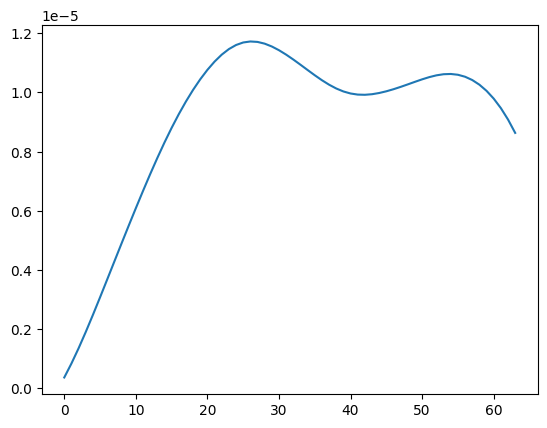

In [ ]:
import matplotlib.pyplot as plt
plt.plot(h_link[0,0,0,:])

